# Why piecewise inequalities are not simple

Modelling inequalities with piecewise linear functions looks like it should just be a
sign flip on the link constraint. **It isn't.** Changing `==` to `<=` in the
piecewise formulation produces a *different mathematical region* than what users
intuitively expect (`y ≤ f(x)`).

This notebook walks through what happens, why, and what the reasonable design
choices are. It was written while deciding whether to add a `sign` parameter to
`add_piecewise_formulation`.

## The question

linopy has two separate tools today:

- `add_piecewise_formulation((x, xp), (y, yp))` — enforces *equality* `y = f(x)` via SOS2/incremental.  Creates auxiliary variables.
- `tangent_lines(x, xp, yp)` — returns a `LinearExpression` giving per-segment tangent lines; user adds `<=` or `>=` against it.  Pure LP.

**Tempting proposal**: let `add_piecewise_formulation(..., sign="<=")` flip the
equality to an inequality. One tool, one flag, done.

**The catch**: that does *not* give the region a user expects from `y ≤ f(x)`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import linopy

## Setup

A concave, monotonically increasing curve with 4 breakpoints.

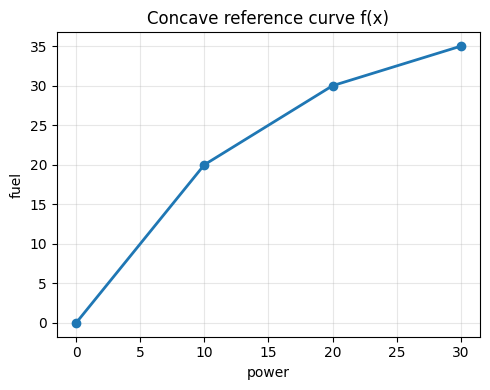

In [2]:
x_pts = np.array([0.0, 10.0, 20.0, 30.0])
y_pts = np.array([0.0, 20.0, 30.0, 35.0])  # slopes 2, 1, 0.5 (concave)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x_pts, y_pts, "o-", color="C0", lw=2)
ax.set(xlabel="power", ylabel="fuel", title="Concave reference curve f(x)")
ax.grid(alpha=0.3)
plt.tight_layout()

## Option A — `tangent_lines` (what users expect `y ≤ f(x)` to mean)

For each segment, `tangent_lines` produces the chord equation `y = m_k x + c_k`.  
The constraint `fuel ≤ tangent_lines(power, …)` broadcasts over segments, so **every
chord's inequality must hold**.  For concave `f`, each segment's chord extended
beyond its own segment lies *above* the curve — so the **intersection** of all
chord inequalities equals the hypograph `{(x, y) : y ≤ f(x)}`.  No auxiliary
variables are created.

In [3]:
m_tan = linopy.Model()
power = m_tan.add_variables(lower=-5, upper=35, name="power")
fuel = m_tan.add_variables(lower=-10, upper=45, name="fuel")
t = linopy.tangent_lines(power, x_pts, y_pts)
m_tan.add_constraints(fuel <= t, name="fuel_bound")

print("variables:", list(m_tan.variables))
print("constraints:", list(m_tan.constraints))

variables: ['power', 'fuel']
constraints: ['fuel_bound']


## Option B — naive `sign="<="` on the equality formulation

What if we take the SOS2 formulation and just flip the link constraint to `<=`?
The internal formulation becomes

$$\sum_i \lambda_i = 1, \qquad \text{SOS2}(\lambda), \qquad \text{power} \le \sum_i \lambda_i x_i, \qquad \text{fuel} \le \sum_i \lambda_i y_i.$$

The solver picks **one** segment (SOS2) and only that segment's inequality has to hold.  That's the **union** of segment constraints, not the intersection.  The feasible region is the **dominated region** — any point below-left of *some* curve point.

Below we sample the plane and colour each point by which formulation accepts it.

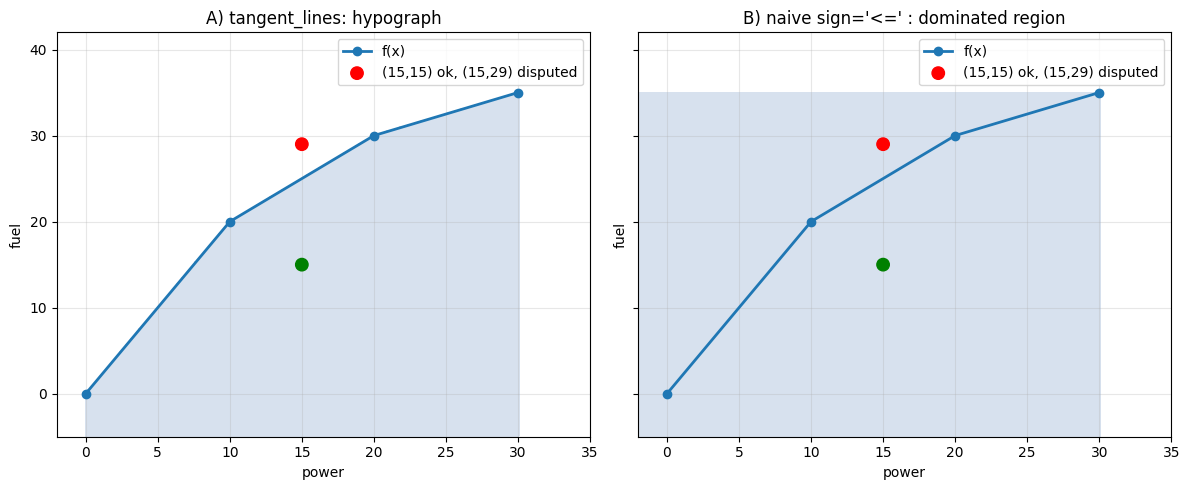

In [4]:
def in_hypograph(px, py):
    if px < x_pts[0] or px > x_pts[-1]:
        return False
    return py <= np.interp(px, x_pts, y_pts)


def in_dominated(px, py):
    # is (px, py) dominated by some point on the piecewise curve?
    for i in range(len(x_pts) - 1):
        xl, xr = x_pts[i], x_pts[i + 1]
        yl, yr = y_pts[i], y_pts[i + 1]
        # parameterise segment as t in [0, 1]
        t_from_x = (px - xl) / (xr - xl) if xr > xl else 0.0
        t_from_y = (py - yl) / (yr - yl) if yr > yl else 0.0
        t_min = max(0.0, t_from_x, t_from_y)
        if t_min <= 1.0:
            return True
    return False


xx, yy = np.meshgrid(np.linspace(-2, 35, 200), np.linspace(-5, 42, 200))
hypo = np.vectorize(in_hypograph)(xx, yy)
domi = np.vectorize(in_dominated)(xx, yy)

# Test points — colour green where feasible, red where infeasible
test_points = [(15, 15), (15, 29)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, region, title, test_fn in [
    (axes[0], hypo, "A) tangent_lines: hypograph", in_hypograph),
    (axes[1], domi, "B) naive sign='<=' : dominated region", in_dominated),
]:
    ax.contourf(xx, yy, region, levels=[0.5, 1], colors=["lightsteelblue"], alpha=0.5)
    ax.plot(x_pts, y_pts, "o-", color="C0", lw=2, label="f(x)")
    colors = ["green" if test_fn(px, py) else "red" for px, py in test_points]
    ax.scatter(
        [p[0] for p in test_points],
        [p[1] for p in test_points],
        color=colors,
        zorder=5,
        s=80,
        edgecolors="black",
        label="green = feasible, red = infeasible",
    )
    for px, py in test_points:
        ax.annotate(f"({px}, {py})", (px, py), textcoords="offset points", xytext=(8, 5))
    ax.set(xlabel="power", ylabel="fuel", title=title)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()

The red point `(15, 29)` is above the curve at `x=15` (`f(15) = 25`). Under
`tangent_lines`, it's infeasible — the chord of segment `[10, 20]` gives
`y ≤ x + 10`, and `29 > 25`. Under `sign="<="`, the solver picks segment
`[20, 30]` with `lambda=1` at the right endpoint. The interpolated point is
`(20, 30)`, which dominates `(15, 29)`. So the SOS2 formulation accepts it.

The dominated region extends to the right and upward in ways that have no
physical interpretation of "fuel ≤ f(power)".

## Why does this happen?

The two formulations differ in how they handle the segment choice:

| | tangent_lines | naive sign="<=" |
|---|---|---|
| Segment choice | Every chord constraint holds | Solver picks one segment (SOS2) |
| Aggregation | **Intersection** of segment bounds | **Union** of segment bounds |
| Result for concave f | Hypograph (tight) | Dominated region (loose) |

**Counterintuitive part**: because SOS2 *adds flexibility* (the solver can pick
which segment to satisfy), the resulting region is **larger**, not smaller.
The sign-flip does not just "relax equality to inequality" — it changes what
each segment contributes.

Users who write `sign="<="` expecting `y ≤ f(x)` get a region that extends
past the curve. No hint in the API surface tells them why.

## Could we "fix" `sign="<="` to give the hypograph?

Yes — by using *different* signs on the x- and y-links:

$$\text{power} \ge \sum_i \lambda_i x_i, \qquad \text{fuel} \le \sum_i \lambda_i y_i.$$

or with equality on x:

$$\text{power} = \sum_i \lambda_i x_i, \qquad \text{fuel} \le \sum_i \lambda_i y_i.$$

Both give the hypograph within the domain. But now the user has to pick *which*
combination — and the answer depends on whether they want power free to extend
past `x_n` or not.

A uniform `sign` flag cannot express this. Per-variable signs can, but then
the user is choosing between three semantics:

1. `(x, xp, "=="), (y, yp, "<=")` — power on curve, fuel bounded
2. `(x, xp, ">="), (y, yp, "<=")` — power free, fuel bounded
3. `(x, xp, "<="), (y, yp, "<=")` — both below frontier (dominated region)

These are *different constraints* that happen to look syntactically similar.
Choosing among them requires the user to understand SOS2 / convex combination
geometry — which is exactly what the piecewise abstraction was supposed to hide.

## What about non-convex curves?

For concave or convex functions, `tangent_lines` gives the tight hypograph or
epigraph as a pure LP. Clean.

For non-convex functions, **no pure-LP formulation can represent the exact
hypograph**. Any linear relaxation collapses to the convex envelope. Options:

1. **Convex envelope relaxation** — reuse `tangent_lines`; you get a loose bound
   suitable for a branch-and-bound outer approximation, not an exact model.
2. **Disjunctive MILP** — split the domain into convex/concave sub-segments,
   pick one with a binary, apply tangent bounds inside. Standard big-M or
   indicator machinery.
3. **Exact equality + auxiliary variable** — use `add_piecewise_formulation` to
   enforce `z = f(x)` exactly (SOS2), then add `y <= z`:

```python
z = m.add_variables(name="z")
m.add_piecewise_formulation((x, xp), (z, yp))   # z = f(x)
m.add_constraints(y <= z)                        # y <= f(x)
```

This is explicit, composable, and the user sees exactly what was added to the
model. No hidden semantics.

None of these are "automatic" — the right choice depends on modelling intent.
A `sign` flag cannot pick for the user without introducing more surprise.

## Conclusion

The motivation for `sign` was "just flip the sign to model an inequality".  The
math does not cooperate:

- Uniform `sign="<="` → **dominated region**, not hypograph.
- Per-tuple signs → recovers hypograph but exposes three semantics and asks
  users to pick.
- Non-convex inequality → has no single "correct" formulation anyway.

The cleaner interface is:

- **`add_piecewise_formulation`** models equality — the natural shape of a
  nonlinear *relationship*.
- **`tangent_lines`** produces a bound expression users apply with
  `<=` / `>=` like any other linear constraint — handles convex/concave cases.
- **Non-convex bounds** use explicit composition with an auxiliary variable.

Each tool has one meaning. The user's modelling intent maps unambiguously to
one of them.